### MIMIC-IV Demo Dataset — Exploratory Data Analysis

**AI Assistance:** Code in this notebook was refined and iterated with the help of **Claude Opus 4.6** (Anthropic) via Kiro IDE.


In [17]:
import pandas as pd
from pathlib import Path 

DATA_PATH = Path(r'c:\Users\i34005\OneDrive - Wood Mackenzie Limited\AI on healthcare\data\mimic-iv-clinical-database-demo-2.2\hosp')

In [18]:
patients = pd.read_csv(DATA_PATH / 'patients.csv.gz')
admissions = pd.read_csv(DATA_PATH / 'admissions.csv.gz')
print(patients.columns.tolist())
print(admissions.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


In [19]:
patient_admissions = admissions.merge(patients, on='subject_id', how='left')

C:\Users\i34005\AppData\Local\Temp\ipykernel_29644\313379055.py:38: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



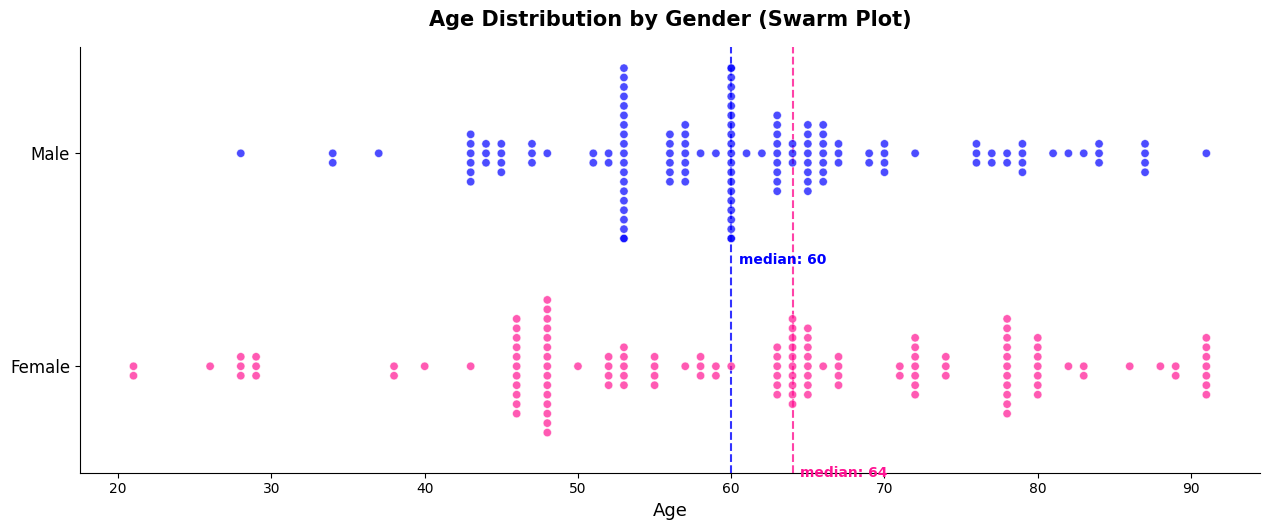

,count,mean,median,min,max
gender,,,,,
Female,133,61.4,64.0,21,91
Male,142,60.7,60.0,28,91


In [20]:
import seaborn as  sns
import matplotlib.pyplot as  plt
from IPython.display import display

plt.style.use('default')

fig, ax = plt.subplots(figsize= (12.8, 5.4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
palette = {
    'M': 'blue',      
    'F': 'deeppink',  
}

sns.swarmplot(
    data=patient_admissions,
    x='anchor_age',
    y='gender',
    hue='gender',
    palette=palette,
    size=6,
    alpha=0.7,
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Add median markers
medians = patient_admissions.groupby('gender')['anchor_age'].median()
for i, gender in enumerate(['M', 'F']):
    ax.axvline(medians[gender], color=palette[gender], linestyle='--', alpha=0.8, linewidth=1.5)
    ax.text(medians[gender] + 0.5, i + 0.5, f'median: {medians[gender]:.0f}',
            color=palette[gender], fontsize=10, fontweight='bold', va='center')

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('')
ax.set_yticklabels(['Male', 'Female'], fontsize=12)
ax.set_title('Age Distribution by Gender (Swarm Plot)', fontsize=15, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Summary table: age statistics by gender
summary = (
    patient_admissions.groupby('gender')['anchor_age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(1)
    .rename(index={'M': 'Male', 'F': 'Female'})
)
display(summary)

In [21]:
import plotly.graph_objects as go
from IPython.display import display

# Build the flow data: admission_location -> discharge_location
flow = patient_admissions.groupby(['admission_location', 'discharge_location']).size().reset_index(name='count')

# Get unique labels
sources = flow['admission_location'].unique().tolist()
targets = flow['discharge_location'].unique().tolist()
labels = sources + targets

# Map to indices
source_indices = [labels.index(s) for s in flow['admission_location']]
target_indices = [labels.index(t) for t in flow['discharge_location']]

# Modern color palette - vibrant gradients
node_colors_src = [
    'rgba(99,110,250,0.9)',   # indigo
    'rgba(239,85,59,0.9)',    # coral
    'rgba(0,204,150,0.9)',    # teal
    'rgba(171,99,250,0.9)',   # purple
    'rgba(255,161,90,0.9)',   # orange
    'rgba(25,211,243,0.9)',   # cyan
    'rgba(255,102,146,0.9)', # pink
    'rgba(182,232,128,0.9)', # lime
    'rgba(246,207,113,0.9)', # gold
    'rgba(102,197,204,0.9)', # seafoam
]

node_colors_tgt = [
    'rgba(99,110,250,0.9)',
    'rgba(239,85,59,0.9)',
    'rgba(0,204,150,0.9)',
    'rgba(171,99,250,0.9)',
    'rgba(255,161,90,0.9)',
    'rgba(25,211,243,0.9)',
    'rgba(255,102,146,0.9)',
    'rgba(182,232,128,0.9)',
    'rgba(246,207,113,0.9)',
    'rgba(102,197,204,0.9)',
    'rgba(220,176,242,0.9)',
    'rgba(159,211,86,0.9)',
]

# Assign node colors
all_node_colors = [node_colors_src[i % len(node_colors_src)] for i in range(len(sources))] + \
                  [node_colors_tgt[i % len(node_colors_tgt)] for i in range(len(targets))]

# Link colors: semi-transparent version of source node color
link_colors = [node_colors_src[labels.index(s) % len(node_colors_src)].replace('0.9', '0.25') for s in flow['admission_location']]

fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=25,
        thickness=25,
        line=dict(color='rgba(0,0,0,0.1)', width=0.5),
        label=[l.title() for l in labels],
        color=all_node_colors,
        hovertemplate='%{label}<br>Total: %{value} patients<extra></extra>',
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=flow['count'].tolist(),
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Patients: %{value}<extra></extra>',
    )
)])

fig.update_layout(
    title=dict(
        text='<b>Patient Flow</b>: Admission Location → Discharge Destination',
        font=dict(size=18, family='Inter, Arial, sans-serif'),
        x=0.5,
        xanchor='center'
    ),
    font=dict(size=11, family='Inter, Arial, sans-serif'),
    template='plotly_white',
    width=1280,
    height=540,
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.show()

# Top 10 admission -> discharge flows
top_flows = (
    flow.sort_values('count', ascending=False)
    .head(10)
    .rename(columns={'admission_location': 'Admission', 'discharge_location': 'Discharge', 'count': 'Patients'})
    .reset_index(drop=True)
)
display(top_flows)

,Admission,Discharge,Patients
0,EMERGENCY ROOM,HOME,38
1,EMERGENCY ROOM,HOME HEALTH CARE,32
2,PHYSICIAN REFERRAL,HOME HEALTH CARE,21
3,EMERGENCY ROOM,SKILLED NURSING FACILITY,18
4,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,17
5,PHYSICIAN REFERRAL,HOME,15
6,TRANSFER FROM HOSPITAL,HOME,10
7,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,8
8,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,7
9,EMERGENCY ROOM,DIED,7


In [22]:
import plotly.express as px
from IPython.display import display

# Prepare data: count admissions by insurance and admission_type
treemap_data = patient_admissions.groupby(['insurance', 'admission_type']).size().reset_index(name='count')

# Add a root column for the treemap hierarchy
treemap_data['root'] = 'All Admissions'

# Assign a distinct color per insurance type (parent level)
insurance_colors = {
    'Other': '#1e40af',      # navy blue
    'Medicare': '#7c3aed',   # violet
    'Medicaid': '#0891b2',   # teal
}
treemap_data['color'] = treemap_data['insurance'].map(insurance_colors)

fig = px.treemap(
    treemap_data,
    path=['root', 'insurance', 'admission_type'],
    values='count',
    color='insurance',
    color_discrete_map={'(?)': '#e2e8f0', **insurance_colors},
    hover_data={'count': True},
)

fig.update_traces(
    textinfo='label+value+percent parent',
    textfont=dict(size=13, family='Inter, Arial, sans-serif', color='white'),
    marker=dict(
        cornerradius=6,
        line=dict(width=2, color='rgba(255,255,255,0.6)'),
        depthfade='reversed',
    ),
    hovertemplate='<b>%{label}</b><br>Admissions: %{value}<br>%{percentParent:.1%} of parent<extra></extra>',
    root_color='rgba(248,249,252,1)',
)

fig.update_layout(
    title=dict(
        text='<b>Admissions Distribution</b><br><sup>Insurance Type → Admission Type | sized by patient count</sup>',
        font=dict(size=20, family='Inter, Arial, sans-serif'),
        x=0.5,
        xanchor='center',
        y=0.97
    ),
    margin=dict(l=10, r=10, t=80, b=10),
    width=1280,
    height=540,
    template='plotly_white',
    showlegend=False,
)

fig.show()

# Pivot table: insurance x admission_type counts
pivot = (
    treemap_data.pivot(index='insurance', columns='admission_type', values='count')
    .fillna(0)
    .astype(int)
)
pivot['Total'] = pivot.sum(axis=1)
display(pivot)

admission_type,AMBULATORY OBSERVATION,DIRECT EMER.,DIRECT OBSERVATION,ELECTIVE,EU OBSERVATION,EW EMER.,OBSERVATION ADMIT,SURGICAL SAME DAY ADMISSION,URGENT,Total
insurance,,,,,,,,,,
Medicaid,0,1,0,1,0,9,6,1,4,22
Medicare,3,3,4,2,16,42,10,8,16,104
Other,2,11,3,10,14,53,29,9,18,149


## Strip Plot: Age Distribution by Gender

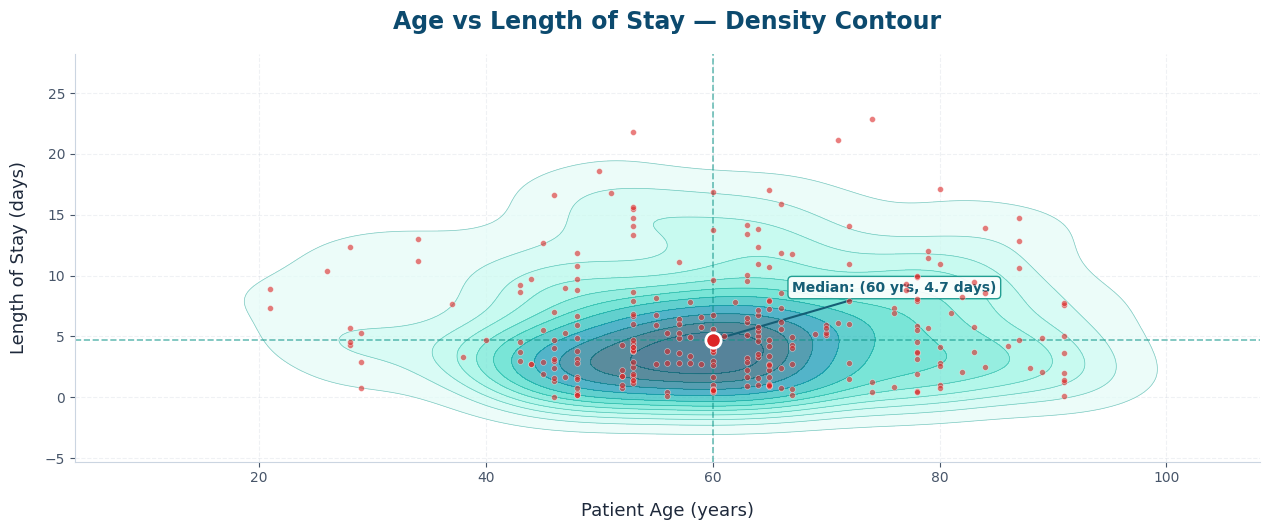

,Age (years),LOS (days)
count,261.00,261.00
mean,61.20,5.73
std,14.54,4.50
min,21.00,0.05
median,60.00,4.69
max,91.00,22.87


Based on 261 admissions (top 5% LOS outliers excluded)


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

# Prepare data
patient_admissions['admittime'] = pd.to_datetime(patient_admissions['admittime'])
patient_admissions['dischtime'] = pd.to_datetime(patient_admissions['dischtime'])
patient_admissions['los_days'] = (patient_admissions['dischtime'] - patient_admissions['admittime']).dt.total_seconds() / 86400

# Filter outliers
plot_data = patient_admissions[patient_admissions['los_days'] <= patient_admissions['los_days'].quantile(0.95)].copy()

fig, ax = plt.subplots(figsize=(12.8, 5.4))
plt.style.use('default')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Healthcare colormap: teal gradient
healthcare_cmap = LinearSegmentedColormap.from_list('healthcare',
    ['#f0fdfa', '#99f6e4', '#2dd4bf', '#0891b2', '#155e75', '#0c4a6e'])

# Filled density contour
sns.kdeplot(
    data=plot_data, x='anchor_age', y='los_days',
    levels=12, fill=True, alpha=0.7, cmap=healthcare_cmap, ax=ax, zorder=2
)

# Teal contour lines
sns.kdeplot(
    data=plot_data, x='anchor_age', y='los_days',
    levels=12, color='#0d9488', linewidths=0.5, alpha=0.5, ax=ax, zorder=3
)

# Scatter points - medical red (like a heartbeat/vital sign)
ax.scatter(
    plot_data['anchor_age'], plot_data['los_days'],
    alpha=0.6, s=18, color='#dc2626', edgecolor='white', linewidth=0.4, zorder=4
)

# Median crosshair
med_age = plot_data['anchor_age'].median()
med_los = plot_data['los_days'].median()
ax.axvline(med_age, color='#0d9488', linestyle='--', alpha=0.6, linewidth=1.2)
ax.axhline(med_los, color='#0d9488', linestyle='--', alpha=0.6, linewidth=1.2)
ax.plot(med_age, med_los, 'o', color='#dc2626', markersize=11,
        markeredgecolor='white', markeredgewidth=2, zorder=6)
ax.annotate(f'Median: ({med_age:.0f} yrs, {med_los:.1f} days)',
            xy=(med_age, med_los), xytext=(med_age + 7, med_los + 4),
            fontsize=10, fontweight='bold', color='#155e75',
            arrowprops=dict(arrowstyle='->', color='#155e75', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#0d9488'))

ax.set_xlabel('Patient Age (years)', fontsize=13, labelpad=12, color='#1e293b')
ax.set_ylabel('Length of Stay (days)', fontsize=13, labelpad=12, color='#1e293b')
ax.set_title('Age vs Length of Stay — Density Contour', fontsize=17, fontweight='bold',
             pad=18, color='#0c4a6e')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')
ax.tick_params(colors='#475569')
ax.grid(alpha=0.15, color='#94a3b8', linestyle='--')

plt.tight_layout()
plt.show()

# Summary statistics for age and length of stay
summary = (
    plot_data[['anchor_age', 'los_days']]
    .describe()
    .loc[['count', 'mean', 'std', 'min', '50%', 'max']]
    .round(2)
    .rename(index={'50%': 'median'}, columns={'anchor_age': 'Age (years)', 'los_days': 'LOS (days)'})
)
display(summary)
print(f'Based on {len(plot_data)} admissions (top 5% LOS outliers excluded)')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
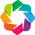

Insurance,Medicaid,Medicare,Other,Total
Race Group,,,,
Black,6,31,14,51
Hispanic/Latino,2,10,3,15
Other Race,7,2,2,11
Unknown/Declined,4,7,12,23
White,3,54,118,175


:Chord   [source,target]   (value)

In [24]:
import holoviews as hv
from holoviews import opts
from IPython.display import display
hv.extension('bokeh')

# Group small race categories into broader groups for a cleaner diagram
race_map = {
    'WHITE': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/CAPE VERDEAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN': 'Hispanic/Latino',
    'HISPANIC OR LATINO': 'Hispanic/Latino',
    'PORTUGUESE': 'Other Race',
    'UNKNOWN': 'Unknown/Declined',
    'UNABLE TO OBTAIN': 'Unknown/Declined',
    'PATIENT DECLINED TO ANSWER': 'Unknown/Declined',
    'OTHER': 'Other Race',
}

# Apply mapping (anything not in map goes to 'Other Race')
chord_df = patient_admissions.copy()
chord_df['race_group'] = chord_df['race'].map(race_map).fillna('Other Race')

# Build the flow data
chord_data = chord_df.groupby(['race_group', 'insurance']).size().reset_index(name='count')
chord_data.columns = ['source', 'target', 'value']

# Create the chord diagram
chord = hv.Chord(chord_data)

chord.opts(
    opts.Chord(
        width=750,
        height=750,
        labels='index',
        label_text_font_size='10pt',
        edge_color='source',
        edge_cmap='Set2',
        edge_alpha=0.5,
        node_color='index',
        node_cmap='Set2',
        node_size=15,
        title='Patient Demographics: Race ↔ Insurance Type',
        fontsize={'title': 14},
    )
)

# Pivot table: race group x insurance counts
pivot = (
    chord_data.pivot(index='source', columns='target', values='value')
    .fillna(0)
    .astype(int)
    .rename_axis(index='Race Group', columns='Insurance')
)
pivot['Total'] = pivot.sum(axis=1)
display(pivot)

chord